In [ ]:
%matplotlib inline
import os, torch, pydicom, warnings
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage
import SimpleITK as sitk
from skimage import morphology, measure, segmentation

warnings.filterwarnings('ignore')

In [ ]:
# ==================== CONFIGURATION ====================
DATA_DIR = "/kaggle/input/datasets/romualdosebany/intertitial-lung-disease/ILD_DB/ILD_DB_volumeROIs"
PATCH_DEPTH, PATCH_HEIGHT, PATCH_WIDTH = 32, 128, 128
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_EPOCHS = 80
BATCH_SIZE = 4

CLASS_NAMES = {0: "Background", 1: "GGO", 2: "Reticulation", 3: "Consolidation"}
NUM_CLASSES = len(CLASS_NAMES)

In [ ]:
# ==================== PREPROCESSING ====================

def resample_to_isotropic(volume, spacing, is_mask=False):
    """Resamples a 3D volume to 1mm isotropic spacing."""
    image = sitk.GetImageFromArray(volume.transpose(2, 0, 1)) 
    image.SetSpacing(spacing)
    new_spacing = [1.0, 1.0, 1.0]
    original_size = image.GetSize()
    original_spacing = image.GetSpacing()
    new_size = [int(round(s * (os / ns))) for s, os, ns in zip(original_size, original_spacing, new_spacing)]
    
    resampler = sitk.ResampleImageFilter()
    resampler.SetSize(new_size)
    resampler.SetOutputSpacing(new_spacing)
    resampler.SetInterpolator(sitk.sitkNearestNeighbor if is_mask else sitk.sitkLinear)
    
    resampled_img = resampler.Execute(image)
    return sitk.GetArrayFromImage(resampled_img).transpose(1, 2, 0)

def extract_lung_mask_3d(volume):
    """Generates a 3D lung mask slice-by-slice."""
    mask_3d = np.zeros_like(volume, dtype=np.float32)
    for i in range(volume.shape[2]):
        slice_2d = volume[:, :, i]
        try:
            binary = slice_2d < -400
            cleared = morphology.remove_small_objects(binary, min_size=100)
            cleared = segmentation.clear_border(cleared)
            labels = measure.label(cleared)
            regions = measure.regionprops(labels)
            if not regions: 
                mask_2d = np.ones_like(slice_2d, dtype=np.float32)
            else:
                regions.sort(key=lambda x: x.area, reverse=True)
                mask_2d = np.zeros_like(slice_2d)
                for rg in regions[:2]: 
                    mask_2d[labels == rg.label] = 1
                mask_2d = ndimage.binary_fill_holes(mask_2d).astype(np.float32)
        except: 
            mask_2d = np.ones_like(slice_2d, dtype=np.float32)
        
        mask_3d[:, :, i] = mask_2d
    return mask_3d

def preprocess_volume(volume, original_spacing):

    # Step 1: Generate Mask and isolate lungs
    mask = extract_lung_mask_3d(volume)
    masked_vol = volume * mask
    
    # [Optional but Highly Recommended for "Massive Overhead Savings"]
    # Crop the volume tightly around the mask regions so you aren't 
    # resampling thousands of voxels of empty background space.
    nonzero = np.argwhere(mask)
    if nonzero.size > 0:
        min_d, min_h, min_w = nonzero.min(axis=0)
        max_d, max_h, max_w = nonzero.max(axis=0) + 1
        masked_vol = masked_vol[min_d:max_d, min_h:max_h, min_w:max_w]
    
    # Step 2: Isotropic Resampling (Now processing a much smaller volume)
    resampled_vol = resample_to_isotropic(masked_vol, original_spacing, is_mask=False)
    
    # Step 3: Intensity Clipping & Min-Max Normalization
    lower, upper = -1350, 150
    clipped_vol = np.clip(resampled_vol, lower, upper)
    normalized_vol = (clipped_vol - lower) / (upper - lower)
    
    return normalized_vol.astype(np.float32)

# ==================== DATA LOADING ====================
def load_patient_data(patient_path):
    patient_id = os.path.basename(patient_path)
    if patient_id in EXCLUDED_PATIENTS: return None, None

    ct_files = sorted([os.path.join(patient_path, f) for f in os.listdir(patient_path) if f.lower().endswith('.dcm')])
    slices, spacing = [], None
    for i, f in enumerate(ct_files):
        try:
            ds = pydicom.dcmread(f)
            if i == 0: spacing = [float(ds.PixelSpacing[0]), float(ds.PixelSpacing[1]), float(getattr(ds, 'SliceThickness', 1.0))]
            img = ds.pixel_array.astype(np.float32)
            if hasattr(ds, 'RescaleSlope'): img = img * ds.RescaleSlope + ds.RescaleIntercept
            slices.append(img)
        except: continue
    
    mask_path = os.path.join(patient_path, 'roi_mask')
    masks = []
    if os.path.exists(mask_path):
        for f in sorted(os.listdir(mask_path)):
            if f.startswith('.'): continue
            try:
                full_m = os.path.join(mask_path, f)
                m = pydicom.dcmread(full_m).pixel_array if f.endswith('.dcm') else np.array(Image.open(full_m).convert('L'))
                # IMPORTANT: Clip values to 0-3 to prevent CUDA DEVICE ASSERT
                m = np.clip(np.round(m), 0, NUM_CLASSES - 1)
                masks.append(m.astype(np.float32))
            except: continue

    if not slices or not masks: return None, None
    min_d = min(len(slices), len(masks))
    vol, mask = np.stack(slices, axis=2)[:,:,:min_d], np.stack(masks, axis=2)[:,:,:min_d]

    if spacing:
        vol = resample_to_isotropic(vol, spacing, is_mask=False)
        mask = resample_to_isotropic(mask, spacing, is_mask=True)
        # Re-verify mask values after interpolation
        mask = np.clip(np.round(mask), 0, NUM_CLASSES - 1)

    if vol.shape[2] < PATCH_DEPTH:
        pad = PATCH_DEPTH - vol.shape[2]
        vol, mask = np.pad(vol, ((0,0), (0,0), (0, pad))), np.pad(mask, ((0,0), (0,0), (0, pad)))

    return preprocess_volume(vol), mask

In [ ]:

# ==================== ARCHITECTURE MODEL ====================
class ResidualBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1), nn.BatchNorm3d(out_ch), nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1), nn.BatchNorm3d(out_ch))
        self.shortcut = nn.Conv3d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x): return F.relu(self.conv(x) + self.shortcut(x))

class UNet3DDeepSup(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        self.enc1, self.enc2, self.enc3 = ResidualBlock3D(1, 32), ResidualBlock3D(32, 64), ResidualBlock3D(64, 128)
        self.pool = nn.MaxPool3d(2)
        self.bottleneck = ResidualBlock3D(128, 256)
        self.up3, self.dec3, self.ds3 = nn.ConvTranspose3d(256, 128, 2, 2), ResidualBlock3D(256, 128), nn.Conv3d(128, n_classes, 1)
        self.up2, self.dec2, self.ds2 = nn.ConvTranspose3d(128, 64, 2, 2), ResidualBlock3D(128, 64), nn.Conv3d(64, n_classes, 1)
        self.up1, self.dec1, self.final = nn.ConvTranspose3d(64, 32, 2, 2), ResidualBlock3D(64, 32), nn.Conv3d(32, n_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1)); e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.dec3(torch.cat([F.interpolate(self.up3(b), size=e3.shape[2:]), e3], 1))
        d2 = self.dec2(torch.cat([F.interpolate(self.up2(d3), size=e2.shape[2:]), e2], 1))
        d1 = self.dec1(torch.cat([F.interpolate(self.up1(d2), size=e1.shape[2:]), e1], 1))
        if self.training:
            out_ds2 = F.interpolate(self.ds2(d2), size=d1.shape[2:], mode='trilinear')
            out_ds3 = F.interpolate(self.ds3(d3), size=d1.shape[2:], mode='trilinear')
            return self.final(d1), out_ds2, out_ds3
        return self.final(d1)

# ==================== DATASET & LOSS ====================
class ILDDataset(Dataset):
    def __init__(self, patches, augment=False): self.patches, self.augment = patches, augment
    def __len__(self): return len(self.patches)
    def __getitem__(self, idx):
        v, m = self.patches[idx]
        v, m = v.copy(), m.copy()
        if self.augment and np.random.rand() > 0.5:
            ax = np.random.choice([0, 1, 2]); v, m = np.flip(v, ax).copy(), np.flip(m, ax).copy()
        return torch.FloatTensor(v).unsqueeze(0).permute(0, 3, 1, 2), torch.LongTensor(m.astype(np.int64)).permute(2, 0, 1)

class MultiClassFocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, gamma=0.75, n_classes=4):
        super().__init__()
        self.alpha, self.beta, self.gamma, self.n_classes = alpha, beta, gamma, n_classes
    def forward(self, inputs, targets):
        inputs = F.softmax(inputs, dim=1)
        # Critical fix: Ensure targets are clamped before one_hot to avoid device asserts
        targets = torch.clamp(targets, 0, self.n_classes - 1)
        targets_one_hot = F.one_hot(targets, self.n_classes).permute(0, 4, 1, 2, 3).float()
        tp = (inputs * targets_one_hot).sum(dim=(0, 2, 3, 4))
        fp = (inputs * (1 - targets_one_hot)).sum(dim=(0, 2, 3, 4))
        fn = ((1 - inputs) * targets_one_hot).sum(dim=(0, 2, 3, 4))
        tversky = (tp + 1e-6) / (tp + self.alpha*fp + self.beta*fn + 1e-6)
        return torch.pow(1 - tversky, self.gamma).mean()

In [ ]:
# ==================== MAIN TRAINING ====================
def main():
    all_paths = [os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) 
                 if os.path.isdir(os.path.join(DATA_DIR, f)) and f != 'HRCT_pilot']
    hrct_dir = os.path.join(DATA_DIR, 'HRCT_pilot')
    if os.path.exists(hrct_dir):
        all_paths += [os.path.join(hrct_dir, f) for f in os.listdir(hrct_dir) if os.path.isdir(os.path.join(hrct_dir, f))]
    
    all_patches = []
    print(f"💎 Filtering and Processing Volumes...")
    for path in tqdm(all_paths):
        vol, mask = load_patient_data(path)
        if vol is not None:
            samples = 60 if 'HRCT' in path else 40
            for _ in range(samples):
                z = np.random.randint(0, vol.shape[2] - 32 + 1)
                y = np.random.randint(0, vol.shape[0] - 128 + 1)
                x = np.random.randint(0, vol.shape[1] - 128 + 1)
                vp, mp = vol[y:y+128, x:x+128, z:z+32], mask[y:y+128, x:x+128, z:z+32]
                if np.sum(mp) > 10 or np.random.rand() > 0.85:
                    all_patches.append((vp, mp))

    # Split datasets
    train_p, val_p = train_test_split(all_patches, test_size=0.15, random_state=42)
    train_loader = DataLoader(ILDDataset(train_p, augment=True), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(ILDDataset(val_p, augment=False), batch_size=BATCH_SIZE)

    model = UNet3DDeepSup(n_classes=NUM_CLASSES).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
    # Background class (0) given lower weight, ILD classes (1-3) given higher weight
    crit_ce = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 15.0, 15.0, 15.0]).to(DEVICE))
    crit_tv = MultiClassFocalTverskyLoss(n_classes=NUM_CLASSES)

    best_dice = 0.0
    for epoch in range(NUM_EPOCHS):
        model.train(); epoch_loss = 0
        for v, m in train_loader:
            v, m = v.to(DEVICE), m.to(DEVICE)
            opt.zero_grad()
            o1, o2, o3 = model(v)
            l1 = crit_ce(o1, m) + 1.5 * crit_tv(o1, m)
            l2 = crit_ce(o2, m) + 1.5 * crit_tv(o2, m)
            l3 = crit_ce(o3, m) + 1.5 * crit_tv(o3, m)
            loss = l1 + 0.5*l2 + 0.25*l3
            loss.backward(); opt.step(); epoch_loss += loss.item()

        model.eval(); v_dice = 0
        with torch.no_grad():
            for v, m in val_loader:
                v, m = v.to(DEVICE), m.to(DEVICE)
                p = model(v).argmax(1)
                dice_batch = 0
                for c in range(1, NUM_CLASSES):
                    p_c, m_c = (p == c), (m == c)
                    dice_batch += (2. * (p_c * m_c).sum() + 1e-6) / (p_c.sum() + m_c.sum() + 1e-6)
                v_dice += dice_batch / (NUM_CLASSES - 1)
        
        avg_dice = (v_dice / len(val_loader)).item()
        print(f"Epoch {epoch+1:02d} | Loss: {epoch_loss/len(train_loader):.4f} | Mean Val Dice: {avg_dice:.4f}")
        
        if avg_dice > best_dice:
            best_dice = avg_dice
            torch.save(model.state_dict(), 'best_multiclass_model.pth')

if __name__ == "__main__":
    main()

💎 Filtering and Processing Volumes...


100%|██████████| 113/113 [02:15<00:00,  1.20s/it]


Epoch 01 | Loss: 2.9570 | Mean Val Dice: 0.2972
Epoch 02 | Loss: 2.8024 | Mean Val Dice: 0.3154
Epoch 03 | Loss: 2.7281 | Mean Val Dice: 0.3255
Epoch 04 | Loss: 2.6517 | Mean Val Dice: 0.2010
Epoch 05 | Loss: 2.6049 | Mean Val Dice: 0.1212
Epoch 06 | Loss: 2.5406 | Mean Val Dice: 0.1228
Epoch 07 | Loss: 2.4407 | Mean Val Dice: 0.1676
Epoch 08 | Loss: 2.3700 | Mean Val Dice: 0.1745
Epoch 09 | Loss: 2.2911 | Mean Val Dice: 0.1816
Epoch 10 | Loss: 2.2189 | Mean Val Dice: 0.2156
Epoch 11 | Loss: 2.1525 | Mean Val Dice: 0.2329
Epoch 12 | Loss: 2.0834 | Mean Val Dice: 0.2493
Epoch 13 | Loss: 2.0116 | Mean Val Dice: 0.3355
Epoch 14 | Loss: 1.9493 | Mean Val Dice: 0.3014
Epoch 15 | Loss: 1.8942 | Mean Val Dice: 0.3681
Epoch 16 | Loss: 1.8451 | Mean Val Dice: 0.3096
Epoch 17 | Loss: 1.8159 | Mean Val Dice: 0.3947
Epoch 18 | Loss: 1.7344 | Mean Val Dice: 0.5447
Epoch 19 | Loss: 1.7311 | Mean Val Dice: 0.3312
Epoch 20 | Loss: 1.6757 | Mean Val Dice: 0.5332
Epoch 21 | Loss: 1.6395 | Mean Val Dice:

KeyboardInterrupt: 

In [2]:
import torch
import numpy as np
from tqdm import tqdm

# Ensure the model is in eval mode
model = UNet3DDeepSup(n_classes=NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load('best_multiclass_model.pth', map_location=DEVICE))
model.eval()

# Metrics Accumulators
tp_total, fp_total, fn_total, tn_total = 0, 0, 0, 0
per_class_dice = {1: [], 2: [], 3: []}

print(f"🔍 Starting Final Evaluation on All Valid Volumes...")

# Re-gather paths (excluding the ones in EXCLUDED_PATIENTS)
all_paths = [os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) 
             if os.path.isdir(os.path.join(DATA_DIR, f)) and f != 'HRCT_pilot']
hrct_dir = os.path.join(DATA_DIR, 'HRCT_pilot')
if os.path.exists(hrct_dir):
    all_paths += [os.path.join(hrct_dir, f) for f in os.listdir(hrct_dir) if os.path.isdir(os.path.join(hrct_dir, f))]

# Filter out excluded patients once more just to be safe
eval_paths = [p for p in all_paths if os.path.basename(p) not in EXCLUDED_PATIENTS]

with torch.no_grad():
    for path in tqdm(eval_paths, desc="Evaluating Volumes"):
        vol, mask = load_patient_data(path)
        if vol is None: continue
        
        # Prepare volume for inference (B, C, D, H, W)
        input_tensor = torch.FloatTensor(vol).unsqueeze(0).unsqueeze(0).permute(0, 1, 4, 2, 3).to(DEVICE)
        
        # Handle large volumes by slicing if necessary, or full volume if memory allows
        # Here we assume standard volume size; for very large ones, use sliding window
        output = model(input_tensor)
        preds = torch.argmax(output, dim=1).cpu().numpy()[0] # Shape: (D, H, W)
        mask = mask.transpose(2, 0, 1) # Align to (D, H, W)
        
        # 1. Global Metrics (Any ILD vs Background)
        # Foreground is classes 1, 2, 3
        pred_fg = (preds > 0)
        gt_fg = (mask > 0)
        
        tp_total += np.sum((pred_fg == 1) & (gt_fg == 1))
        fp_total += np.sum((pred_fg == 1) & (gt_fg == 0))
        fn_total += np.sum((pred_fg == 0) & (gt_fg == 1))
        tn_total += np.sum((pred_fg == 0) & (gt_fg == 0))
        
        # 2. Per-Class Dice (for internal tracking)
        for c in range(1, NUM_CLASSES):
            p_c = (preds == c)
            m_c = (mask == c)
            if np.sum(m_c) > 0: # Only count if class exists in ground truth
                dice_c = (2. * np.sum(p_c & m_c)) / (np.sum(p_c) + np.sum(m_c) + 1e-6)
                per_class_dice[c].append(dice_c)

# Final Metric Calculations
precision = tp_total / (tp_total + fp_total + 1e-6)
recall = tp_total / (tp_total + fn_total + 1e-6)
mean_dice = (2 * tp_total) / (2 * tp_total + fp_total + fn_total + 1e-6)
iou = tp_total / (tp_total + fp_total + fn_total + 1e-6)
specificity = tn_total / (tn_total + fp_total + 1e-6)

# Printing the results in your exact requested format
print("\n" + "🎯 FINAL EVALUATION RESULTS - ALL VOLUMES")
print("="*90)
print(f"Dice Score      : {mean_dice:.4f} ({mean_dice*100:.2f}%)")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"IoU (Jaccard)   : {iou:.4f}")
print(f"Specificity     : {specificity:.4f}")
print(f"TP / FP / FN / TN : {tp_total:,} / {fp_total:,} / {fn_total:,} / {tn_total:,}")
print("-" * 90)
print("PER-CLASS BREAKDOWN (DICE):")
for c in range(1, NUM_CLASSES):
    avg_c = np.mean(per_class_dice[c]) if per_class_dice[c] else 0.0
    print(f" - {CLASS_NAMES[c]}: {avg_c:.4f}")
print("="*90)

🔍 Starting Final Evaluation on All Valid Volumes...


Evaluating Volumes: 100%|██████████| 113/113 [02:55<00:00,  1.55s/it]


🎯 FINAL EVALUATION RESULTS - ALL VOLUMES
Dice Score      : 0.7935 (79.35%)
Precision       : 0.7265
Recall          : 0.8740
IoU (Jaccard)   : 0.6577
Specificity     : 0.9970
TP / FP / FN / TN : 3,669,568 / 1,381,160 / 528,841 / 462,590,831
------------------------------------------------------------------------------------------
PER-CLASS BREAKDOWN (DICE):
 - GGO: 0.8436
 - Reticulation: 0.7000
 - Consolidation: 0.7209


📊 Generating Confusion Matrix...


100%|██████████| 113/113 [02:33<00:00,  1.36s/it]


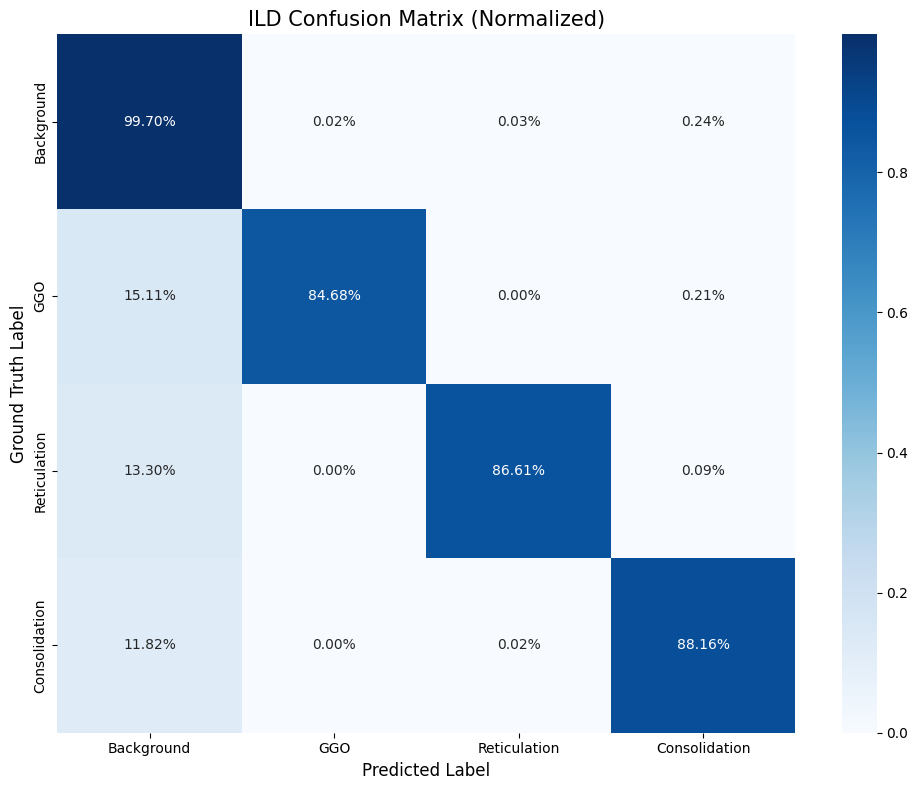

In [3]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Initialize Confusion Matrix
cm_total = np.zeros((NUM_CLASSES, NUM_CLASSES))

print("📊 Generating Confusion Matrix...")
with torch.no_grad():
    for path in tqdm(eval_paths):
        vol, mask = load_patient_data(path)
        if vol is None: continue
        
        input_tensor = torch.FloatTensor(vol).unsqueeze(0).unsqueeze(0).permute(0, 1, 4, 2, 3).to(DEVICE)
        output = model(input_tensor)
        preds = torch.argmax(output, dim=1).cpu().numpy().flatten()
        mask_flat = mask.transpose(2, 0, 1).flatten()
        
        # Accumulate Confusion Matrix counts
        cm_total += confusion_matrix(mask_flat, preds, labels=range(NUM_CLASSES))

# Normalize the matrix by row (percentage of Ground Truth)
cm_perc = cm_total.astype('float') / (cm_total.sum(axis=1)[:, np.newaxis] + 1e-6)

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm_perc, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
            yticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)])
plt.title('ILD Confusion Matrix (Normalized)', fontsize=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Ground Truth Label', fontsize=12)
plt.tight_layout()
plt.show()